Meeting: 12:30 Friday 2/10/26

Attendance:
Ben X
Tobias X

Recap:
We divided the project in two. Ben will look at stellar population and Tobias will look at dynamics.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rc
%matplotlib inline
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

In [3]:
harris_p1 = pd.read_csv('HarrisPartI.csv')
harris_p2 = pd.read_csv('HarrisPartII.csv')
harris_p3 = pd.read_csv('HarrisPartIII.csv')

Stellar population analysis - Ben

Stellar dynamics analysis - Tobias

In [56]:
R_gc = pd.to_numeric(harris_p1['R_gc'],errors='coerce')
R_Sun = pd.to_numeric(harris_p1['R_Sun'],errors='coerce')
sig_v = pd.to_numeric(harris_p3['sig_v'],errors='coerce')
v_r = pd.to_numeric(harris_p3['v_r'],errors='coerce')
mtlc = pd.to_numeric(harris_p2['[Fe/H]'],errors='coerce')
rho_0 = pd.to_numeric(harris_p3['rho_0'],errors='coerce')
mu_V = pd.to_numeric(harris_p3['mu_V'],errors='coerce')
c = pd.to_numeric(harris_p3['c'],errors='coerce')
BmV = pd.to_numeric(harris_p2['B-V'],errors='coerce')
ellip = pd.to_numeric(harris_p2['ellip'],errors='coerce')
r_c = pd.to_numeric(harris_p3['r_c'],errors='coerce')
r_h = pd.to_numeric(harris_p3['r_h'],errors='coerce')
M_V = pd.to_numeric(harris_p2['M_V,t'],errors='coerce')
V_t = pd.to_numeric(harris_p2['V_t'],errors='coerce')

mask = mtlc > -0.8

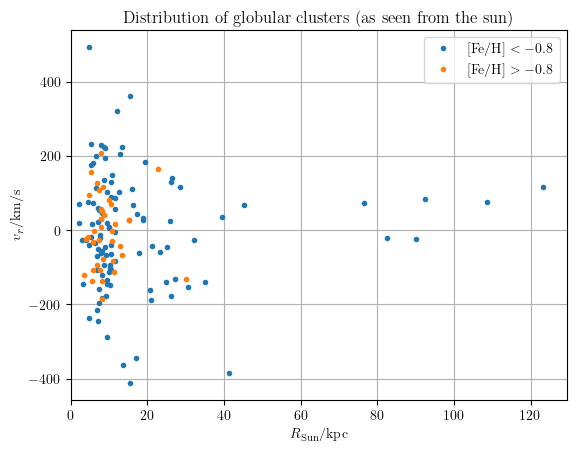

In [5]:
plt.figure()
plt.plot(R_Sun[~mask],v_r[~mask],'.',label=r'$[\mathrm{Fe/H}] < -0.8$')
plt.plot(R_Sun[mask],v_r[mask],'.',label=r'$[\mathrm{Fe/H}] > - 0.8$')
plt.legend()
plt.xlabel(r'$R_{\mathrm{Sun}}/\mathrm{kpc}$')
plt.ylabel(r'$v_r/\mathrm{km/s}$')
plt.grid()
plt.xlim(0)
plt.title(r'Distribution of globular clusters (as seen from the sun)')
plt.show()

C:\Users\Elhol\AppData\Local\Temp\ipykernel_26108\3602336219.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


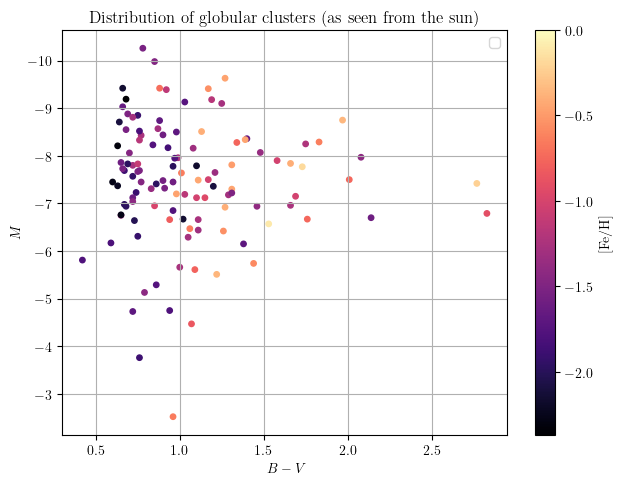

In [103]:
plt.figure()
S_05 = np.sqrt(5*v_r**2+sig_v**2)
plt.scatter(BmV,M_V,15,mtlc,cmap='magma',vmin=mtlc.min(),vmax=mtlc.max())
plt.colorbar(label =r'$[\mathrm{Fe/H}]$')
plt.xlabel(r'$B-V$')
plt.ylabel(r'$M$')
plt.legend()
plt.grid()
# plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.xlim()
plt.title(r'Distribution of globular clusters (as seen from the sun)')
plt.show()

In [73]:
from scipy.interpolate import RBFInterpolator
BmV_space = np.linspace(BmV.min(),BmV.max(),1000)
M_space = np.linspace(M_V.min(),M_V.max(),1000)
BmV_space,M_space = np.meshgrid(BmV_space,M_space)
mask2 = np.isnan(M_V) | np.isnan(BmV) | np.isnan(mtlc)
M_V_arr = M_V[~mask2]
BmV_arr = BmV[~mask2]
mtlc_arr = mtlc[~mask2]
BmVM = np.transpose(np.array([BmV_arr,M_V_arr]))
rbf = RBFInterpolator(BmVM,mtlc_arr, kernel = 'thin_plate_spline')

# MM = griddata(RV,M_array,(RR,VV),method = 'cubic')
mtlc_space = rbf(np.column_stack((BmV_space.ravel(), M_space.ravel()))).reshape(BmV_space.shape)

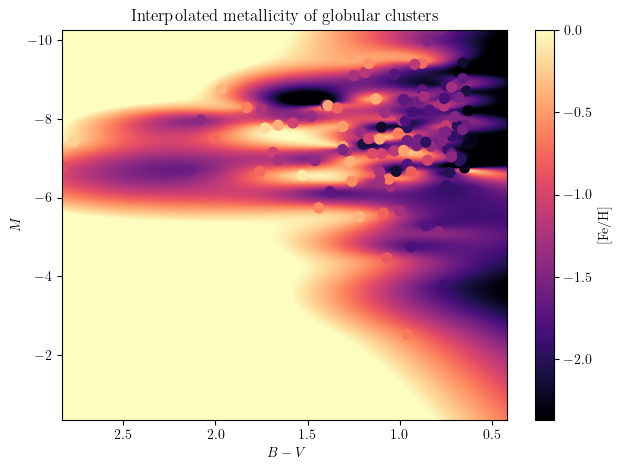

In [74]:
plt.figure()
plt.pcolormesh(BmV_space,M_space,mtlc_space,cmap='magma',vmin=mtlc.min(),vmax=mtlc.max())
plt.scatter(BmV,M_V,50,mtlc,cmap='magma',vmin=mtlc.min(),vmax=mtlc.max())
plt.colorbar(label =r'$[\mathrm{Fe/H}]$')
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel(r'$B-V$')
plt.ylabel(r'$M$')
plt.title(r'Interpolated metallicity of globular clusters')
plt.tight_layout()
plt.show()